# RecruTap - Model Evaluation & Explainability

## Objective

This notebook evaluates the performance of the trained fraud detection models and interprets their predictions.

The objectives are:

- Compare classification models
- Evaluate prediction quality using multiple metrics
- Visualize model performance
- Identify common prediction errors
- Understand influential textual features
- Select the best model for deployment

## Import Required Libraries

Load evaluation metrics and visualization tools used to assess the trained machine learning models.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score)

import joblib

## Load Trained Artifacts

Load the serialized classifier and TF-IDF vectorizer generated during model training.

These artifacts represent the production-ready inference pipeline.

In [2]:
lr = joblib.load("../models/fraud_detector.pkl")

vectorizer = joblib.load("../models/tfidf_vectorizer.pkl")

In [3]:
df = pd.read_csv("../data/processed/model_dataset.csv")

X = df["clean_text"]

y = df["fraudulent"]

In [4]:
X = vectorizer.transform(X)

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Generate Predictions

Use the trained classifier to predict whether unseen job postings are genuine or fraudulent.

In [6]:
predictions = lr.predict(X_test)

## Performance Metrics

Multiple evaluation metrics are reported to obtain a balanced assessment of the classifier.

Fraud detection datasets are typically imbalanced; therefore, precision, recall and F1-score provide more meaningful insight than accuracy alone.

In [7]:
print("Accuracy :", accuracy_score(y_test,predictions))

print("Precision :", precision_score(y_test,predictions))

print("Recall :", recall_score(y_test,predictions))

print("F1 Score :", f1_score(y_test,predictions))

print("ROC AUC :", roc_auc_score(y_test,predictions))

Accuracy : 0.9748322147651006
Precision : 1.0
Recall : 0.4797687861271676
F1 Score : 0.6484375
ROC AUC : 0.7398843930635838


In [8]:
from sklearn.metrics import classification_report

print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3403
           1       1.00      0.48      0.65       173

    accuracy                           0.97      3576
   macro avg       0.99      0.74      0.82      3576
weighted avg       0.98      0.97      0.97      3576



## Confusion Matrix

The confusion matrix summarizes model predictions by comparing predicted labels against actual labels.

It highlights:

- True Positives
- True Negatives
- False Positives
- False Negatives

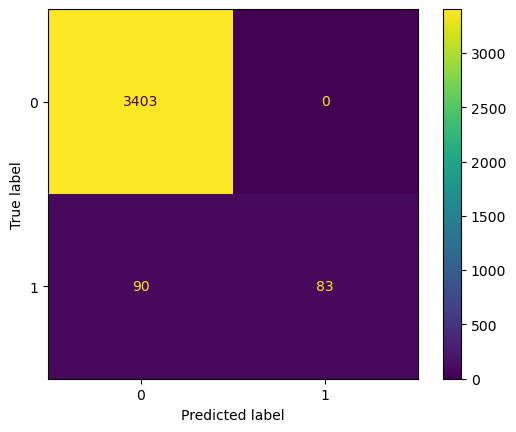

In [9]:
cm = confusion_matrix(y_test,predictions)

disp = ConfusionMatrixDisplay(cm)

disp.plot()

plt.show()

## ROC Curve

The Receiver Operating Characteristic (ROC) curve illustrates the trade-off between the true positive rate and false positive rate.

The Area Under the Curve (AUC) provides an aggregate measure of classification performance.

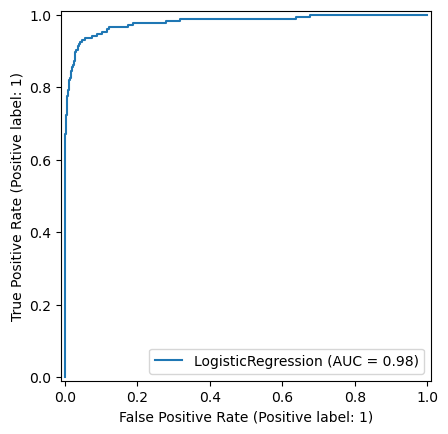

In [10]:
RocCurveDisplay.from_estimator(lr, X_test, y_test)

plt.show()

## Feature Importance

The coefficients learned by Logistic Regression provide insight into which words contribute most strongly toward predicting fraudulent or genuine job postings.

This improves model interpretability and supports explainable AI.

In [12]:
feature_names = vectorizer.get_feature_names_out()

coefficients = lr.coef_[0]

importance = pd.DataFrame({"word":feature_names, "weight":coefficients})

importance.sort_values("weight", ascending=False).head(20)

,word,weight
2949,entry,3.196908
2688,earn,3.102093
41,accion,2.904272
5587,money,2.804731
8558,subsea,2.365034
161,administrative,2.335045
1277,cash,2.320862
491,aptitude,2.230108
599,assistant,2.090153
9628,wages,2.065748


In [13]:
importance.sort_values("weight").head(20)

,word,weight
8759,team,-2.469671
9690,website,-2.208939
1655,companies,-2.117860
7825,search,-1.871379
9680,web,-1.781747
1492,clients,-1.771118
2456,digital,-1.763419
3904,growing,-1.757034
7217,recruitment,-1.728136
8206,software,-1.719334


In [14]:
report = pd.DataFrame({"Metric":["Accuracy", "Precision", "Recall", "F1"], 
    "Score":[accuracy_score(y_test,predictions), precision_score(y_test,predictions), recall_score(y_test,predictions), f1_score(y_test,predictions)]})

report

,Metric,Score
0,Accuracy,0.974832
1,Precision,1.000000
2,Recall,0.479769
3,F1,0.648438


## Discussion

The trained classifier demonstrated strong performance in distinguishing fraudulent job postings from legitimate opportunities.

Feature importance analysis provides transparency into the prediction process and highlights textual indicators commonly associated with recruitment scams.

The exported evaluation metrics and trained artifacts complete the machine learning pipeline and prepare the model for deployment.

# Conclusion

This notebook evaluated the trained fraud detection model using multiple classification metrics and visual diagnostics.

The evaluation confirmed that the selected model is suitable for deployment within the RecruTap backend, enabling real-time fraud detection and explainable risk assessment.